In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
import random as rand
init_printing(use_latex=True)
filename = "DataGeneric.xlsx"
# My functions:
from SolveRMSE import SolveRMSE

In [ ]:
pTrain = 10
pTest = 20
#rand.seed(1)
SolveRMSE(filename, pTrain, pTest, ridgeCoef=100, k=6, suppress=False)

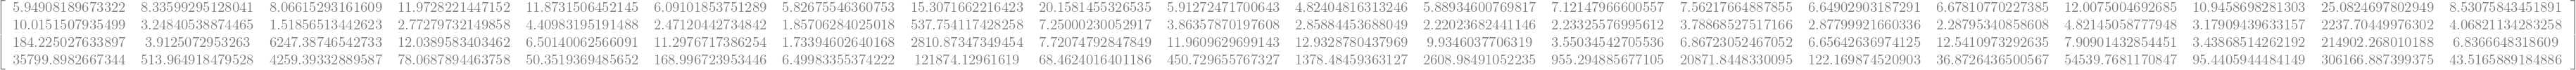

In [5]:
kk = 4
numRuns = 20
RMSEs = zeros(kk,numRuns)
# Use same random seeds for each k.
seeds = np.random.randint(10**10, size=numRuns)
for k in range(kk):
    for run in range(numRuns):
        rand.seed(int(seeds[run]))
        RMSEs[k,run] = SolveRMSE(filename, pTrain, pTest, ridgeCoef=0, k=k, suppress=True)
    
RMSEs

In [6]:
# Calculate Standard Deviations
stds = np.zeros(kk)
for k in range(kk):
    stds[k] = np.std(np.array(RMSEs[k,:]).astype(float))
# Calculate means
means = np.array([np.mean(RMSEs[i,:]) for i in range(kk)]).astype(float)
# Calculate 95% CIs
uppers = [means[k] + 1.96*stds[k]/np.sqrt(numRuns) for k in range(kk)]
lowers = [means[k] - 1.96*stds[k]/np.sqrt(numRuns) for k in range(kk)]
means, stds, lowers, uppers

(array([9.73918984e+00, 1.42060047e+02, 1.12135294e+04, 2.75044880e+04]),
 array([5.12083902e+00, 4.94630821e+02, 4.67520513e+04, 7.00648559e+04]),
 [7.494883183296881,
  -74.72146804181364,
  -9276.46053243445,
  -3202.7890165850113],
 [11.98349649410875, 358.8415627828202, 31703.519244178147, 58211.76500782975])

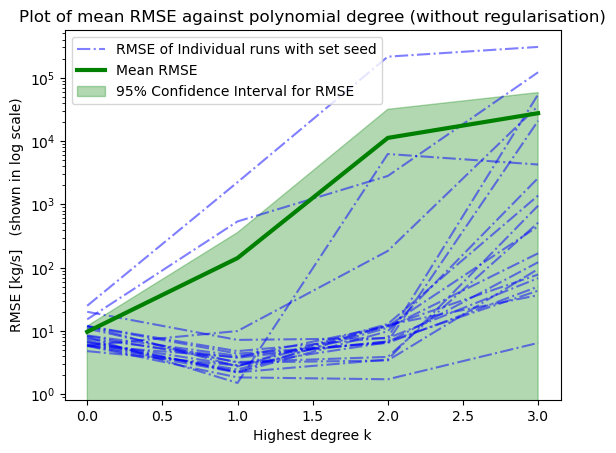

In [8]:
for run in range(numRuns):
    if run==0:
        plt.plot(range(kk), RMSEs[:,run], "b-.", alpha=0.5, label="RMSE of Individual runs with set seed")
    else:
        plt.plot(range(kk), RMSEs[:,run], "b-.", alpha=0.5)
plt.plot(range(kk), means, "g-", lw=3, label="Mean RMSE")
plt.fill_between(range(kk), lowers, uppers, color="g", alpha=0.3, label="95% Confidence Interval for RMSE")
plt.yscale("log")
plt.title("Plot of mean RMSE against polynomial degree (without regularisation)")
plt.xlabel("Highest degree k")
plt.ylabel("RMSE [kg/s]   (shown in log scale)")
plt.legend()


In [105]:
k

In [1]:
means, lowers, uppers


NameError: name 'means' is not defined

In [107]:
run

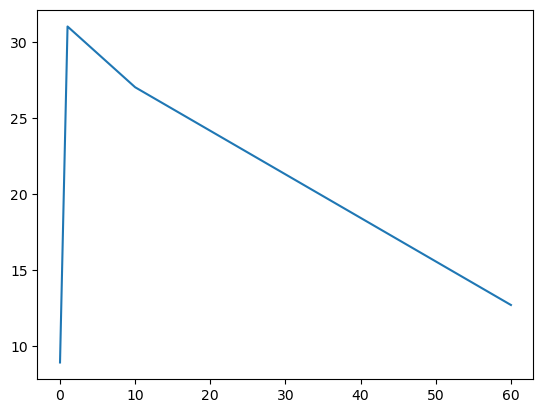

In [9]:
ridges = [0, 1, 10, 60]
numRuns = 5

RMSEss = np.zeros(len(ridges))
for i in range(len(ridges)):
    for run in range(numRuns):
        RMSEss[i] = RMSEss[i] + SolveRMSE(filename, pTrain, pTest, ridgeCoef=ridges[i], k=2, suppress=True)
    RMSEss[i] = RMSEss[i] / numRuns
plt.plot(ridges, RMSEss)